## Import Data

In [1]:
from google.colab import drive
drive.mount('/content/drive')
data_dir = "/content/drive/MyDrive/RevFracture/Bone Break Classification"

from tensorflow.keras import utils

Mounted at /content/drive


In [2]:
# load the train data

train_data = utils.image_dataset_from_directory(
    data_dir,
    class_names=['Avulsion fracture', 'Comminuted fracture', 'Fracture Dislocation', 'Greenstick fracture', 'Hairline Fracture', 'Impacted fracture', 'Longitudinal fracture', 'Normal', 'Oblique fracture', 'Pathological fracture', 'Spiral Fracture'],
    label_mode="int",
    validation_split=0.1,
    subset="training",
    shuffle=True,
    color_mode="rgb",
    image_size=(256,256),
    batch_size=64,
    seed=40
)

#load the test data
validation_data = utils.image_dataset_from_directory(
    data_dir,
    class_names=['Avulsion fracture', 'Comminuted fracture', 'Fracture Dislocation', 'Greenstick fracture', 'Hairline Fracture', 'Impacted fracture', 'Longitudinal fracture', 'Normal', 'Oblique fracture', 'Pathological fracture', 'Spiral Fracture'],
    label_mode="int",
    validation_split=0.1,
    subset="validation",
    color_mode="rgb",
    image_size=(256,256),
    batch_size=64,
    seed=42
)

Found 1344 files belonging to 11 classes.
Using 1210 files for training.
Found 1344 files belonging to 11 classes.
Using 134 files for validation.


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow import keras
from keras import (
    backend as K,
    losses,
    optimizers,
    layers,
    models,
    utils,
    callbacks
)

from pathlib import Path

In [4]:
# Inspect class names
class_names = train_data.class_names
print("Class names:", class_names)

Class names: ['Avulsion fracture', 'Comminuted fracture', 'Fracture Dislocation', 'Greenstick fracture', 'Hairline Fracture', 'Impacted fracture', 'Longitudinal fracture', 'Normal', 'Oblique fracture', 'Pathological fracture', 'Spiral Fracture']


In [5]:
# data preprocessing
def preprocess(img):
    img = tf.cast(img, "float32") / 255.0
    return img

train_dataset = train_data.map(lambda x, y: (preprocess(x), y))
val_dataset = validation_data.map(lambda x, y: (preprocess(x), y))

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])


In [6]:
# This cell is no longer needed as the dataset is fed directly to the model for training.
# The data loading and preprocessing are handled by the train_data and validation_data objects.
# Removing the code to collect data into NumPy arrays.

# x_train = []
# y_train = []

# for images, labels in train_dataset:
#     try:
#         x_train.append(images.numpy())
#         y_train.append(labels.numpy())
#     except tf.errors.InvalidArgumentError as e:
#         print(f"Skipping invalid image file: {e}")
#         continue

# x_train = np.concatenate(x_train, axis=0)
# y_train = np.concatenate(y_train, axis=0)

print("Data loading and preprocessing is handled by the dataset objects. Proceed to model training.")

Data loading and preprocessing is handled by the dataset objects. Proceed to model training.


In [7]:
# get val data and labels

x_val = []
y_val = []

for images, labels in val_dataset:
    #append train data to x_train
    x_val.append(images.numpy())

    #append labels to y_train
    y_val.append(labels.numpy())

# concatenate all the batches to get the full list
x_val = np.concatenate(x_val, axis=0)
y_val = np.concatenate(y_val, axis=0)

In [24]:
import cv2

path = "/content/drive/MyDrive/RevFracture/Bone Break Classification/Non Xray/Train/bunga.jpg"
img = cv2.imread(path)
print(img is None)


False


In [25]:
import cv2, os

folder = "/content/drive/MyDrive/RevFracture/Bone Break Classification/Non Xray/Train"
bad_files = []

for file in os.listdir(folder):
    if file.lower().endswith((".jpg", ".jpeg", ".png")):
        path = os.path.join(folder, file)
        img = cv2.imread(path)
        if img is None:
            bad_files.append(file)

print("🚫 File rusak/tidak terbaca:", bad_files if bad_files else "Semua OK ✅")


🚫 File rusak/tidak terbaca: Semua OK ✅


In [8]:
import os
import tensorflow as tf

# Replace with the actual path to your dataset directory
data_dir = "/content/drive/MyDrive/RevFracture/Bone Break Classification"

for subdir, dirs, files in os.walk(data_dir):
    for file in files:
        filepath = os.path.join(subdir, file)
        try:
            # Attempt to load the file as an image using TensorFlow
            img = tf.io.read_file(filepath)
            img = tf.image.decode_image(img, channels=3) # Try to decode as a 3-channel image (RGB)
            # If decoding is successful, you could add more checks here if needed
        except tf.errors.InvalidArgumentError as e:
            print(f"Error decoding image file: {filepath} - {e}")
        except Exception as e:
            print(f"An unexpected error occurred with file: {filepath} - {e}")

Error decoding image file: /content/drive/MyDrive/RevFracture/Bone Break Classification/Non Xray/Train/bunga.jpg - {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, PNG, GIF, BMP required. [Op:DecodeImage] name: 
Error decoding image file: /content/drive/MyDrive/RevFracture/Bone Break Classification/Non Xray/Test/bunga.jpg - {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, PNG, GIF, BMP required. [Op:DecodeImage] name: 


In [9]:
import os

# Replace with the actual path to your dataset directory
data_dir = "/content/drive/MyDrive/RevFracture/Bone Break Classification"

for subdir, dirs, files in os.walk(data_dir):
    for file in files:
        filepath = os.path.join(subdir, file)
        try:
            # Attempt to open and read a small portion of the file
            with open(filepath, 'rb') as f:
                f.read(10) # Read the first 10 bytes to check if it's readable
            # If the file is readable, you could add more specific checks here
            # for example, using a library to verify image headers.
        except Exception as e:
            print(f"Error reading file: {filepath} - {e}")

In [10]:
import os

file_path = "/content/drive/MyDrive/RevFracture/Bone Break Classification/Normal/Test/9.png"
if os.path.exists(file_path):
    print(f"The file {file_path} exists.")
else:
    print(f"The file {file_path} does not exist.")

The file /content/drive/MyDrive/RevFracture/Bone Break Classification/Normal/Test/9.png exists.


In [11]:
# get single batch from train data

def sample_batch(data):
    batch = data.take(1).get_single_element()
    if isinstance(batch, tuple):
        batch = batch[0]
    return batch.numpy()

In [12]:
class_names_dict = {
    0: 'Avulsion fracture',
    1: 'Comminuted fracture',
    2: 'Fracture Dislocation',
    3: 'Greenstick fracture',
    4: 'Hairline Fracture',
    5: 'Impacted fracture',
    6: 'Longitudinal fracture',
    7: 'Oblique fracture',
    8: 'Pathological fracture',
    9: 'Spiral Fracture',
    10: 'Normal',
    11: 'Non Xray'
}

In [13]:
# function to display images

def display(dataset, n=10, size=(15,5), cmap="gray_r", as_type="float32"):
    """
    Displays a sample of images and their class names from a TensorFlow dataset.

    Args:
        dataset: A TensorFlow dataset object.
        n (int): The number of images to display.
        size (tuple): The size of the matplotlib figure.
        cmap (str): The colormap to use for displaying images.
        as_type (str): The data type to cast the image data to before displaying.
    """
    # Take one batch from the dataset
    batch = dataset.take(1).get_single_element()
    images, labels = batch

    # Ensure we don't try to display more images than available in the batch
    n = min(n, len(images))

    num_images_per_row = 4
    num_rows = (n + num_images_per_row - 1) // num_images_per_row

    # Set up the subplots
    fig, axes = plt.subplots(num_rows, num_images_per_row, figsize=size)
    axes = axes.flatten() # Flatten the axes array for easy iteration

    # Get class names from the globally available class_names variable
    global class_names


    for i in range(n):
        # Get the integer label
        label_index = labels[i].numpy()

        # Convert integer label to class name
        class_name = class_names[label_index]

        # Display the image
        axes[i].imshow(images[i].numpy().astype(as_type), cmap=cmap)
        axes[i].set_title(f'Class: {class_name}')
        axes[i].axis('off')

    # Hide any unused subplots
    for j in range(n, len(axes)):
        axes[j].axis('off')


    plt.subplots_adjust(wspace=0.5, hspace=0.5)
    plt.show()

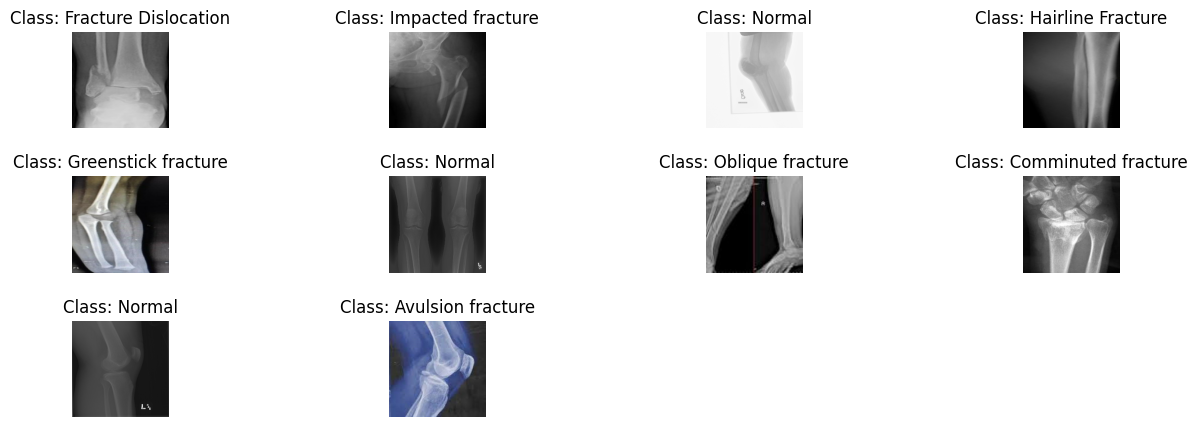

In [14]:
# display sample train images

# Use the updated display function with the train_dataset
display(train_dataset, n=10)

In [15]:
# view tensor shape

# x_train.shape

In [16]:
# one-hot encode the train, val data

NUM_CLASSES = len(class_names)

# y_train = utils.to_categorical(y_train, NUM_CLASSES)
# y_val = utils.to_categorical(y_val, NUM_CLASSES)

## CNN

In [17]:
input_layer = layers.Input(shape=(256,256,3))
x = data_augmentation(input_layer)

x = layers.Conv2D(
    filters=32,
    kernel_size=(3,3),
    strides=2,
    padding="same"
)(input_layer)
x = layers.BatchNormalization(momentum=0.9)(x)
x = layers.LeakyReLU(0.2)(x)
x = layers.Dropout(rate=0.2)(x)

x = layers.Conv2D(
    64,
    3,
    strides=2,
    padding="same"
)(x)
x = layers.BatchNormalization(momentum=0.9)(x)
x = layers.LeakyReLU(0.2)(x)
x = layers.Dropout(rate=0.2)(x)

x = layers.Conv2D(
    128,
    3,
    strides=2,
    padding="same"
)(x)
x = layers.BatchNormalization(momentum=0.9)(x)
x = layers.LeakyReLU(0.2)(x)
x = layers.Dropout(rate=0.2)(x)

x = layers.Conv2D(
    256,
    3,
    strides=2,
    padding="same"
)(x)
x = layers.BatchNormalization(momentum=0.9)(x)
x = layers.LeakyReLU(0.2)(x)
x = layers.Dropout(rate=0.2)(x)

x = layers.Flatten()(x)

x = layers.Dense(units=100)(x)
x = layers.BatchNormalization(momentum=0.9)(x)
x = layers.LeakyReLU(0.2)(x)
x = layers.Dropout(rate=0.2)(x)

output_layer = layers.Dense(units=NUM_CLASSES, activation="softmax")(x)

model2 = models.Model(input_layer, output_layer)

model2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │     6,553,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 6,945,547 (26.50 MB)

 Trainable params: 6,944,387 (26.49 MB)

 Non-trainable params: 1,160 (4.53 KB)

In [18]:
opt = optimizers.Adam(learning_rate=0.0005)
model2.compile(loss="sparse_categorical_crossentropy", optimizer=opt, metrics=["accuracy"])

In [19]:
# save checkpoints to monitor best performing models

model_checkpoint_callback = callbacks.ModelCheckpoint(
    filepath="./checkpoint.keras",
    save_weights_only = False,
    save_freq = "epoch",
    monitor = "loss",
    mode = "min",
    save_best_only = True,
    verbose = 0
)

tensorboard_callback = callbacks.TensorBoard(log_dir="./logs")

In [20]:
history = model2.fit(
    train_dataset,
    epochs=16,
    validation_data=val_dataset,
    callbacks=[
        model_checkpoint_callback,
        tensorboard_callback,
    ]
)

Epoch 1/16
19/19 ━━━━━━━━━━━━━━━━━━━━ 121s 6s/step - accuracy: 0.2102 - loss: 2.4358 - val_accuracy: 0.1642 - val_loss: 2.6552
Epoch 2/16
19/19 ━━━━━━━━━━━━━━━━━━━━ 111s 6s/step - accuracy: 0.4251 - loss: 1.7213 - val_accuracy: 0.2164 - val_loss: 2.4858
Epoch 3/16
19/19 ━━━━━━━━━━━━━━━━━━━━ 114s 6s/step - accuracy: 0.5653 - loss: 1.3892 - val_accuracy: 0.5000 - val_loss: 1.7988
Epoch 4/16
19/19 ━━━━━━━━━━━━━━━━━━━━ 133s 5s/step - accuracy: 0.7263 - loss: 0.9376 - val_accuracy: 0.8358 - val_loss: 0.7416
Epoch 5/16
19/19 ━━━━━━━━━━━━━━━━━━━━ 139s 5s/step - accuracy: 0.8841 - loss: 0.5248 - val_accuracy: 0.9403 - val_loss: 0.4108
Epoch 6/16
19/19 ━━━━━━━━━━━━━━━━━━━━ 117s 6s/step - accuracy: 0.9513 - loss: 0.3003 - val_accuracy: 0.9552 - val_loss: 0.2844
Epoch 7/16
19/19 ━━━━━━━━━━━━━━━━━━━━ 104s 5s/step - accuracy: 0.9821 - loss: 0.1920 - val_accuracy: 0.9701 - val_loss: 0.2010
Epoch 8/16
19/19 ━━━━━━━━━━━━━━━━━━━━ 104s 5s/step - accuracy: 0.9873 - loss: 0.1443 - val_accuracy: 0.9627 - v

In [21]:
train_loss = history.history["loss"]
train_accuracy = history.history["accuracy"]
val_loss = history.history["val_loss"]
val_accuracy = history.history["val_accuracy"]


In [22]:
model2.save("/content/drive/MyDrive/RevFracture/fractureCNNRev_model.h5")


In [27]:
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, accuracy_score
import numpy as np

# Convert y_val from one-hot encoded to integer labels if it is not already
if y_val.ndim > 1:
    y_val_integer = np.argmax(y_val, axis=1)
else:
    y_val_integer = y_val

model2.evaluate(x_val, y_val_integer)

# --- Prediksi pada validation set ---
y_pred_probs = model2.predict(x_val)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_val_integer

# --- Hitung metrik utama ---
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
average_recall = recall  # sama untuk macro average

print("📊 Evaluation Metrics (Validation Set):")
print(f"Akurasi        : {accuracy:.4f}")
print(f"Presisi (macro): {precision:.4f}")
print(f"Recall (macro) : {recall:.4f}")
print(f"Average Recall : {average_recall:.4f}")

# --- Classification Report ---
print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 309ms/step - accuracy: 0.9681 - loss: 0.1367
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 309ms/step
📊 Evaluation Metrics (Validation Set):
Akurasi        : 0.9552
Presisi (macro): 0.9522
Recall (macro) : 0.9348
Average Recall : 0.9348

📋 Classification Report:
                       precision    recall  f1-score   support

    Avulsion fracture       0.92      1.00      0.96        12
  Comminuted fracture       0.93      0.93      0.93        15
 Fracture Dislocation       0.94      1.00      0.97        17
  Greenstick fracture       1.00      0.80      0.89        10
    Hairline Fracture       1.00      1.00      1.00        10
    Impacted fracture       0.75      0.75      0.75         8
Longitudinal fracture       0.92      1.00      0.96        12
               Normal       1.00      1.00      1.00        23
     Oblique fracture       1.00      1.00      1.00        11
Pathological fracture       1.00      1.00      1.00        11
      Spiral Fracture       1.00 

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

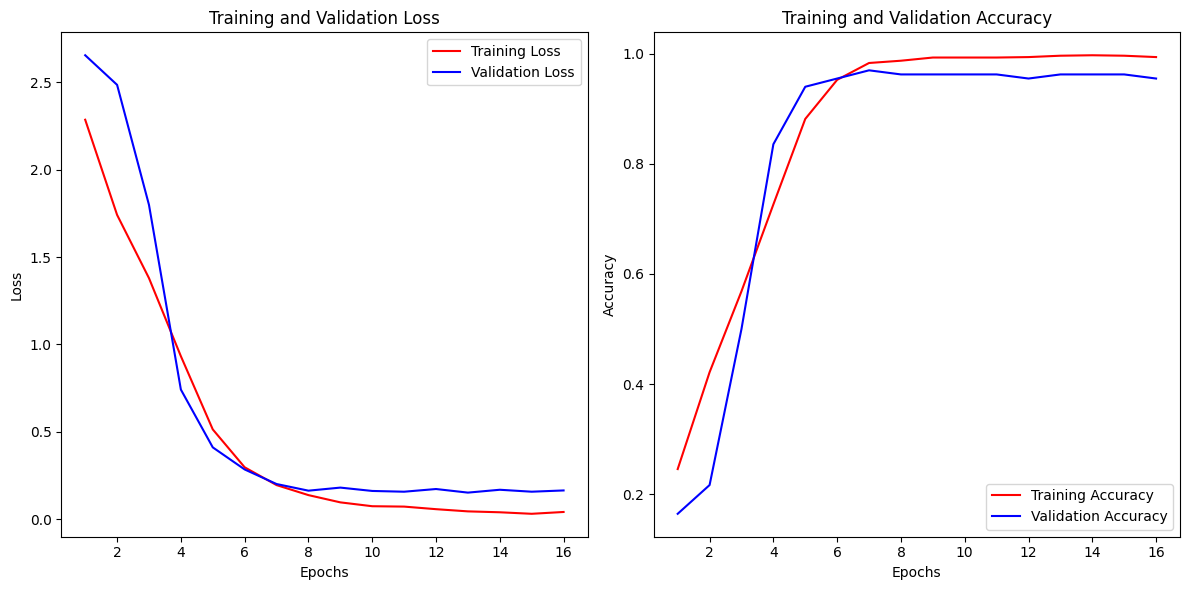

In [29]:
# plot learning curve

epochs= range(1,17)

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.plot(epochs, train_loss, 'r-', label="Training Loss")
plt.plot(epochs, val_loss, 'b-', label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, train_accuracy, 'r-', label="Training Accuracy")
plt.plot(epochs, val_accuracy, 'b-', label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [30]:
#predictions

preds = model2.predict(x_val)

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 299ms/step


In [31]:
preds_single = [class_names[np.argmax(pred)] for pred in preds]
actual_single = [class_names[np.argmax(label)] for label in y_val]

In [32]:
#Predictions

def display_preds_act(n=10):
    """
    Displays a comparison of predicted and actual class names for a sample of validation data.

    Args:
        n (int[): The number of samples to display.
    """
    indices = np.random.choice(len(preds_single), n)

    print("Displaying Sample Predictions vs Actuals:")
    for i, index in enumerate(indices):
        print(f"Sample {i+1}: Predicted - {preds_single[index]}, Actual - {actual_single[index]}")

display_preds_act()

Displaying Sample Predictions vs Actuals:
Sample 1: Predicted - Longitudinal fracture, Actual - Avulsion fracture
Sample 2: Predicted - Pathological fracture, Actual - Avulsion fracture
Sample 3: Predicted - Greenstick fracture, Actual - Avulsion fracture
Sample 4: Predicted - Longitudinal fracture, Actual - Avulsion fracture
Sample 5: Predicted - Avulsion fracture, Actual - Avulsion fracture
Sample 6: Predicted - Greenstick fracture, Actual - Avulsion fracture
Sample 7: Predicted - Longitudinal fracture, Actual - Avulsion fracture
Sample 8: Predicted - Greenstick fracture, Actual - Avulsion fracture
Sample 9: Predicted - Impacted fracture, Actual - Avulsion fracture
Sample 10: Predicted - Fracture Dislocation, Actual - Avulsion fracture


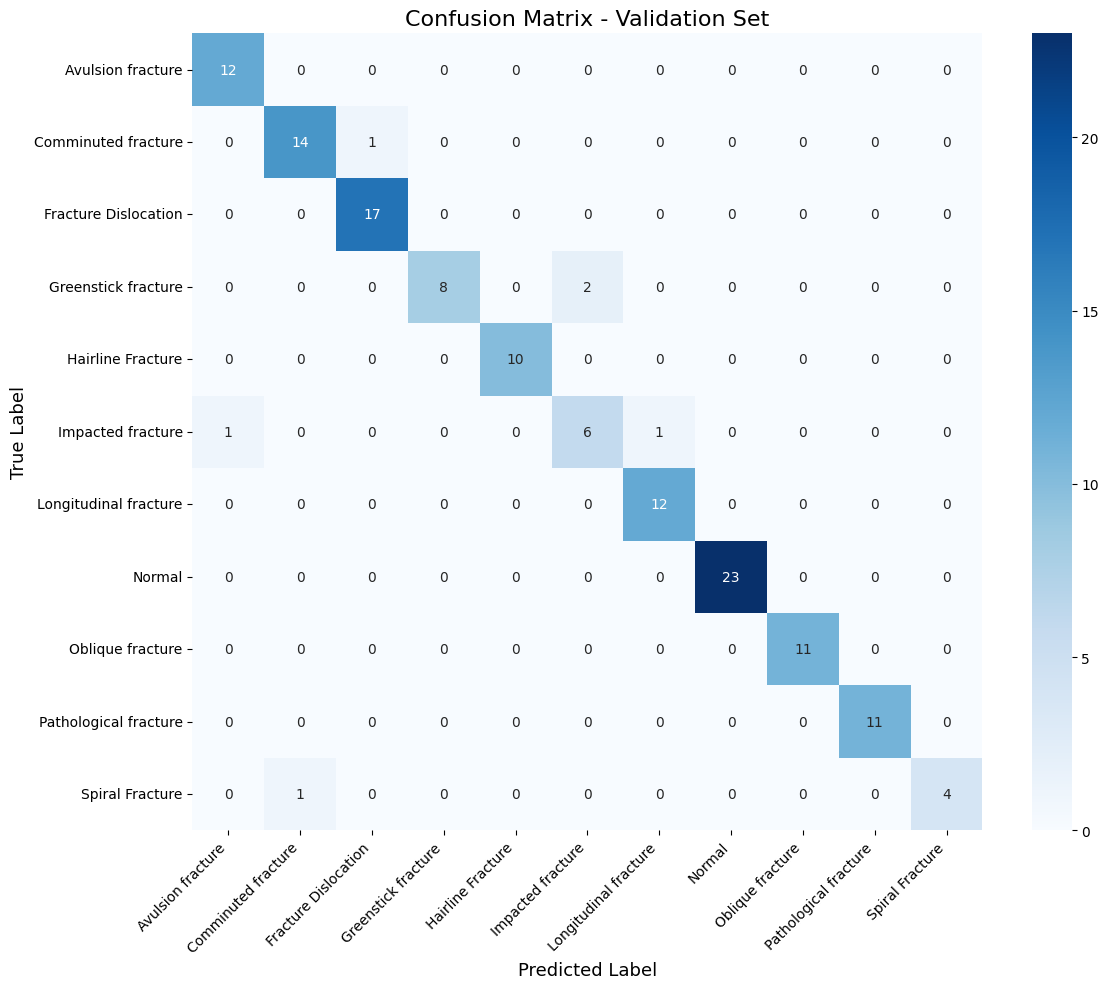

In [33]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Validation Set", fontsize=16)
plt.xlabel("Predicted Label", fontsize=13)
plt.ylabel("True Label", fontsize=13)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/RevFracture/confusion_matrix_final.png", dpi=300)
plt.show()


In [34]:
from tensorflow.keras.models import load_model
model = load_model("/content/drive/MyDrive/RevFracture/fractureCNNRev_model.h5")

In [35]:
import json

metrics = {
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "average_recall": average_recall
}

with open("/content/drive/MyDrive/RevFracture/evaluation_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

print("✅ Evaluation metrics saved to: /content/drive/MyDrive/RevFracture/evaluation_metrics.json")


✅ Evaluation metrics saved to: /content/drive/MyDrive/RevFracture/evaluation_metrics.json


In [36]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.models import Model

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """
    Membuat heatmap Grad-CAM (kompatibel TensorFlow 2.17+)
    """
    # Ambil layer terakhir yang mengandung feature map
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Lacak gradient dari output kelas terhadap feature map terakhir
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    # Gradien tiap channel feature map
    grads = tape.gradient(class_channel, conv_outputs)

    # Rata-rata gradien untuk tiap channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Ambil hasil aktivasi terakhir
    conv_outputs = conv_outputs[0].numpy()
    pooled_grads = pooled_grads.numpy()

    # Hitung heatmap Grad-CAM
    for i in range(pooled_grads.shape[-1]):
        conv_outputs[:, :, i] *= pooled_grads[i]

    heatmap = np.mean(conv_outputs, axis=-1)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap) if np.max(heatmap) != 0 else 1

    return heatmap


In [37]:
def display_gradcam(img_path, model, last_conv_layer_name, class_names):
    # Load gambar
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(256, 256))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Prediksi
    preds = model.predict(img_array)
    class_index = np.argmax(preds[0])
    predicted_class = class_names[class_index]
    confidence = preds[0][class_index] * 100

    print(f"Predicted: {predicted_class} ({confidence:.2f}%)")

    # Buat heatmap Grad-CAM
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

    # Konversi heatmap ke bentuk overlay
    img = cv2.imread(img_path)
    img = cv2.resize(img, (256, 256))
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Overlay antara heatmap dan gambar asli
    superimposed_img = cv2.addWeighted(heatmap, 0.4, img, 0.6, 0)

    cv2.imwrite("/content/drive/MyDrive/RevFracture/gradcam_result.jpg", superimposed_img)
    print("✅ Grad-CAM image saved to Drive!")


    # Tampilkan hasil
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original X-ray")

    plt.subplot(1,2,2)
    plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Grad-CAM: {predicted_class}")
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Predicted: Avulsion fracture (99.90%)


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 256, 256, 3))
  warnings.warn(msg)


✅ Grad-CAM image saved to Drive!


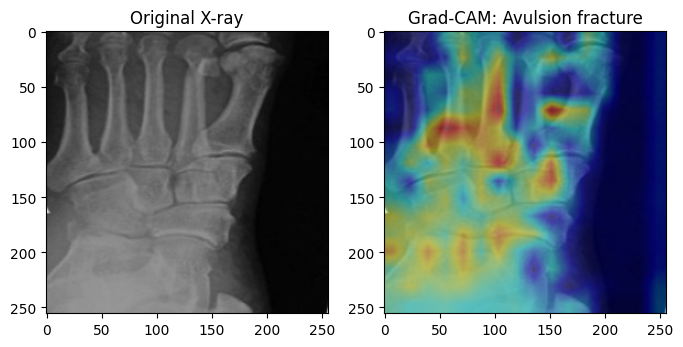

In [38]:
# Ganti dengan path gambar uji kamu
test_image_path = "/content/drive/MyDrive/RevFracture/Bone Break Classification/Avulsion fracture/Test/Gambar2.jpg"

# Ganti dengan nama layer Conv2D terakhir di model kamu (lihat model.summary())
display_gradcam(test_image_path, model2, last_conv_layer_name="conv2d_3", class_names=class_names)

In [39]:
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │     6,553,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 6,945,549 (26.50 MB)

 Trainable params: 6,944,387 (26.49 MB)

 Non-trainable params: 1,160 (4.53 KB)

 Optimizer params: 2 (12.00 B)

In [40]:
# Inspect the input structure expected by the grad_model
# This helps understand why the warning about input shape mismatch is occurring
# based on the structure of the grad_model's inputs attribute.

last_conv_layer_name = "conv2d_3"
grad_model = tf.keras.models.Model(
    [model2.inputs],
    [model2.get_layer(last_conv_layer_name).output, model2.output]
)

print("Expected input structure for grad_model:")
print(grad_model.inputs)

Expected input structure for grad_model:
[<KerasTensor shape=(None, 256, 256, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor>]


In [41]:
for layer in model.layers:
    if 'conv' in layer.name:
        print(layer.name)


conv2d
conv2d_1
conv2d_2
conv2d_3
